# 04 - Label Bootstrapping

Generates catalog ground-truth labels using two dedicated offline teacher models:
- **Category (4 classes):** `deberta-v3-large` via zero-shot NLI entailment.
- **Emotion (4 classes):** `emotion-english-distilroberta-base` (renormalized to 4 target classes).

---

### Key Highlights
- **Why Two Models?** Prevents NLI hypothesis collapse (e.g. 83% `surprise`) and domain mismatch.
- **Label Alignment:** Normalizes 4 core emotions (`fear`, `joy`, `neutral`, `sadness`) and persists continuous probability distributions.
- **Checkpointed Batching:** Automatically saves progress every 2,000 rows to `data/_teacher_labels_checkpoint.csv` for resilient execution.


In [11]:
import sys
import time
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import pipeline

from app.config import (
    CATALOG_CSV,
    CATEGORIES,
    DATA_DIR,
    EMOTION_MODEL_NAME,
    EMOTIONS,
    TEACHER_MODEL_NAME,
    build_passage_text,
    get_logger,
)

logger = get_logger("label_bootstrapping")

MAX_TEACHER_INPUT_CHARS = 400
CHECKPOINT_EVERY_ROWS = 2000
CHECKPOINT_PATH = DATA_DIR / "_teacher_labels_checkpoint.csv"
EMOTION_SCORE_COLUMNS = [f"emotion_score_{label}" for label in EMOTIONS]

catalog = pd.read_csv(CATALOG_CSV, dtype={"isbn13": "string"})
logger.info("Loaded catalog: %d rows, %d columns", *catalog.shape)

# Re-running this notebook (e.g. after swapping either offline model or the
# emotion taxonomy) may load a catalog.csv that already carries a previous
# run's label columns. Drop them first so the merge below always adds a
# clean column instead of colliding into pandas' "_x"/"_y" suffixes.
PREVIOUS_LABEL_COLUMNS = ["category", "category_confidence", "emotion", "emotion_confidence", *EMOTION_SCORE_COLUMNS]
existing_label_columns = [col for col in PREVIOUS_LABEL_COLUMNS if col in catalog.columns]
if existing_label_columns:
    logger.info("Dropping pre-existing label columns from an earlier run: %s", existing_label_columns)
    catalog = catalog.drop(columns=existing_label_columns)

catalog["_teacher_text"] = [
    build_passage_text(row.title, row.categories, row.description)[:MAX_TEACHER_INPUT_CHARS]
    for row in catalog.itertuples()
]


2026-08-17 19:42:29 | INFO    | booklens.label_bootstrapping | Loaded catalog: 22568 rows, 19 columns
2026-08-17 19:42:29 | INFO    | booklens.label_bootstrapping | Dropping pre-existing label columns from an earlier run: ['category', 'category_confidence', 'emotion', 'emotion_confidence', 'emotion_score_fear', 'emotion_score_joy', 'emotion_score_neutral', 'emotion_score_sadness']


## 1. Load Offline Teacher Models

Initializes the zero-shot NLI category teacher and DistilRoBERTa emotion classifier with GPU/MPS support if available.


In [2]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = 0
else:
    device = -1

device_label = {"mps": "mps", 0: "cuda:0", -1: "cpu"}[device]

logger.info("Loading category teacher %s on device=%s", TEACHER_MODEL_NAME, device_label)
category_teacher = pipeline("zero-shot-classification", model=TEACHER_MODEL_NAME, device=device)

logger.info("Loading emotion classifier %s on device=%s", EMOTION_MODEL_NAME, device_label)
emotion_classifier = pipeline("text-classification", model=EMOTION_MODEL_NAME, top_k=None, device=device)


2026-08-17 18:42:47 | INFO    | booklens.label_bootstrapping | Loading category teacher MoritzLaurer/deberta-v3-large-mnli-fever-anli-ling-wanli on device=mps


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

2026-08-17 18:42:53 | INFO    | booklens.label_bootstrapping | Loading emotion classifier j-hartmann/emotion-english-distilroberta-base on device=mps


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

## 2. Checkpointed Batch Labeling

Processes the catalog in chunks, appending predictions to disk to allow safe resumption.


In [3]:
def load_checkpoint() -> pd.DataFrame:
    """Load already-labeled rows from disk, or an empty frame if none exist yet."""
    if CHECKPOINT_PATH.exists():
        checkpoint = pd.read_csv(CHECKPOINT_PATH, dtype={"isbn13": "string"})
        logger.info("Resuming from checkpoint: %d rows already labeled", len(checkpoint))
        return checkpoint
    return pd.DataFrame(columns=["_catalog_index", "category", "category_confidence", "emotion", "emotion_confidence", *EMOTION_SCORE_COLUMNS])


def classify_category_task(texts, batch_size=32):
    """Run the NLI teacher over `texts` for category, returning (label, confidence) pairs."""
    results = category_teacher(
        list(texts),
        candidate_labels=CATEGORIES,
        hypothesis_template="This text is about {}.",
        batch_size=batch_size,
    )
    if isinstance(results, dict):  # a single text returns a dict, not a list
        results = [results]
    return [(r["labels"][0], r["scores"][0]) for r in results]


def classify_emotion_task(texts, batch_size=32):
    """
    Run the dedicated emotion classifier over `texts`, keeping only the
    labels in EMOTIONS (dropping `disgust`, plus `anger`/`surprise` per the
    taxonomy trim - see this notebook's intro) and renormalizing the rest
    to sum to 1 before taking the argmax.

    Returns (label, confidence, score_by_label) tuples - score_by_label is
    the full renormalized distribution, persisted as emotion_score_<label> columns.
    """
    all_scores = emotion_classifier(list(texts), batch_size=batch_size, truncation=True)
    predictions = []
    for per_text_scores in all_scores:
        kept = {entry["label"]: entry["score"] for entry in per_text_scores if entry["label"] in EMOTIONS}
        total = sum(kept.values())
        renormalized = {label: kept.get(label, 0.0) / total for label in EMOTIONS}
        best_label = max(renormalized, key=renormalized.get)
        predictions.append((best_label, renormalized[best_label], renormalized))
    return predictions


def run_label_bootstrapping(catalog: pd.DataFrame) -> pd.DataFrame:
    """
    Label every not-yet-checkpointed row for both category (NLI teacher)
    and emotion (dedicated emotion classifier), saving a checkpoint every
    CHECKPOINT_EVERY_ROWS rows.

    Returns a DataFrame with columns: _catalog_index, category,
    category_confidence, emotion, emotion_confidence, emotion_score_<label>
    (one per EMOTIONS label) - one row per book.
    """
    checkpoint = load_checkpoint()
    already_done = set(checkpoint["_catalog_index"])
    remaining = catalog[~catalog.index.isin(already_done)]

    if remaining.empty:
        logger.info("All %d rows already labeled from checkpoint", len(catalog))
        return checkpoint

    new_rows = []
    start_time = time.time()

    for chunk_start in range(0, len(remaining), CHECKPOINT_EVERY_ROWS):
        chunk = remaining.iloc[chunk_start : chunk_start + CHECKPOINT_EVERY_ROWS]

        category_results = classify_category_task(chunk["_teacher_text"])
        emotion_results = classify_emotion_task(chunk["_teacher_text"])

        for row_index, (category, category_conf), (emotion, emotion_conf, emotion_scores) in zip(
            chunk.index, category_results, emotion_results
        ):
            new_rows.append({
                "_catalog_index": row_index,
                "category": category,
                "category_confidence": category_conf,
                "emotion": emotion,
                "emotion_confidence": emotion_conf,
                **{f"emotion_score_{label}": emotion_scores[label] for label in EMOTIONS},
            })

        checkpoint = pd.concat([checkpoint, pd.DataFrame(new_rows)], ignore_index=True)
        checkpoint.to_csv(CHECKPOINT_PATH, index=False)

        rows_done = len(checkpoint)
        elapsed_minutes = (time.time() - start_time) / 60
        logger.info(
            "Labeled %d/%d rows (%.1f%%) - %.1f minutes elapsed",
            rows_done, len(catalog), 100 * rows_done / len(catalog), elapsed_minutes,
        )
        new_rows = []

    return checkpoint


teacher_labels = run_label_bootstrapping(catalog)


2026-08-17 18:48:19 | INFO    | booklens.label_bootstrapping | Labeled 2000/22568 rows (8.9%) - 5.4 minutes elapsed
2026-08-17 18:53:07 | INFO    | booklens.label_bootstrapping | Labeled 4000/22568 rows (17.7%) - 10.2 minutes elapsed
2026-08-17 18:58:13 | INFO    | booklens.label_bootstrapping | Labeled 6000/22568 rows (26.6%) - 15.3 minutes elapsed
2026-08-17 19:03:48 | INFO    | booklens.label_bootstrapping | Labeled 8000/22568 rows (35.4%) - 20.9 minutes elapsed
2026-08-17 19:09:16 | INFO    | booklens.label_bootstrapping | Labeled 10000/22568 rows (44.3%) - 26.3 minutes elapsed
2026-08-17 19:14:36 | INFO    | booklens.label_bootstrapping | Labeled 12000/22568 rows (53.2%) - 31.7 minutes elapsed
2026-08-17 19:23:01 | INFO    | booklens.label_bootstrapping | Labeled 14000/22568 rows (62.0%) - 40.1 minutes elapsed
2026-08-17 19:26:08 | INFO    | booklens.label_bootstrapping | Labeled 16000/22568 rows (70.9%) - 43.2 minutes elapsed
2026-08-17 19:29:30 | INFO    | booklens.label_bootstr

## 3. Merge & Save Labeled Catalog

Merges bootstrapped labels and full emotion distributions into `data/catalog.csv`.


In [4]:
catalog = catalog.merge(
    teacher_labels.set_index("_catalog_index")[
        ["category", "category_confidence", "emotion", "emotion_confidence", *EMOTION_SCORE_COLUMNS]
    ],
    left_index=True, right_index=True, how="left",
)
catalog = catalog.drop(columns=["_teacher_text"])

missing_labels = catalog["category"].isna() | catalog["emotion"].isna()
if missing_labels.any():
    logger.warning("%d rows failed to get a teacher label - dropping them", missing_labels.sum())
    catalog = catalog[~missing_labels].reset_index(drop=True)

catalog.to_csv(CATALOG_CSV, index=False)
logger.info("Saved catalog with teacher labels: %d rows, %d columns", *catalog.shape)

CHECKPOINT_PATH.unlink(missing_ok=True)
logger.info("Removed checkpoint file - labeling is complete")


2026-08-17 19:37:45 | INFO    | booklens.label_bootstrapping | Saved catalog with teacher labels: 22568 rows, 19 columns
2026-08-17 19:37:45 | INFO    | booklens.label_bootstrapping | Removed checkpoint file - labeling is complete


## 4. Category & Emotion Distributions

Visualizes the final catalog label distributions across all 4 categories and 4 emotions.


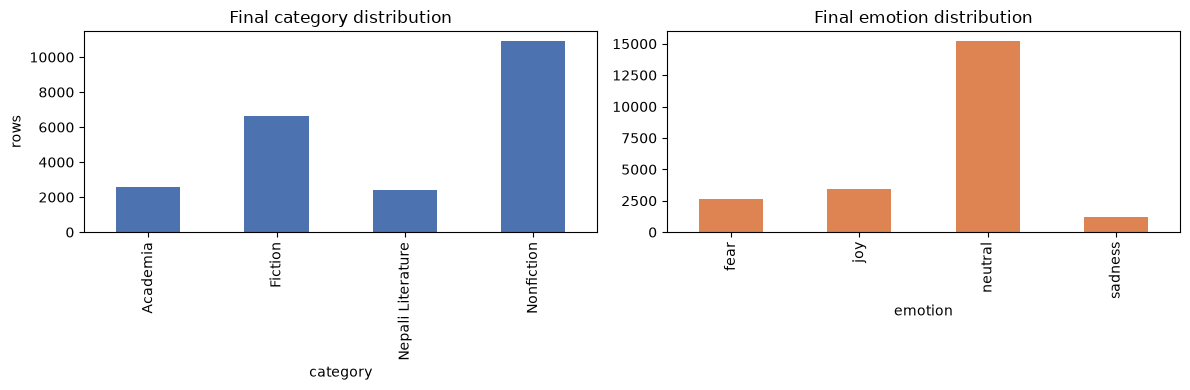

2026-08-17 19:44:45 | INFO    | booklens.label_bootstrapping | Final category distribution:
category
Nonfiction           10926
Fiction               6612
Academia              2598
Nepali Literature     2432
2026-08-17 19:44:45 | INFO    | booklens.label_bootstrapping | Final emotion distribution:
emotion
neutral    15227
joy         3470
fear        2648
sadness     1223


In [13]:
from app.config import CATALOG_CSV
import pandas as pd

catalog = pd.read_csv(CATALOG_CSV, dtype={"isbn13": "string"})


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

catalog["category"].value_counts().reindex(CATEGORIES).plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Final category distribution")
axes[0].set_ylabel("rows")

catalog["emotion"].value_counts().reindex(EMOTIONS).plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Final emotion distribution")

plt.tight_layout()
plt.show()

logger.info("Final category distribution:\n%s", catalog["category"].value_counts().to_string())
logger.info("Final emotion distribution:\n%s", catalog["emotion"].value_counts().to_string())
